In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [217]:
produk = pd.read_csv('product_category.csv')

In [218]:
produk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  200 non-null    int64
 1   Price   200 non-null    int64
 2   Label   200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


In [219]:
produk['Label'].value_counts()

Label
0    100
1    100
Name: count, dtype: int64

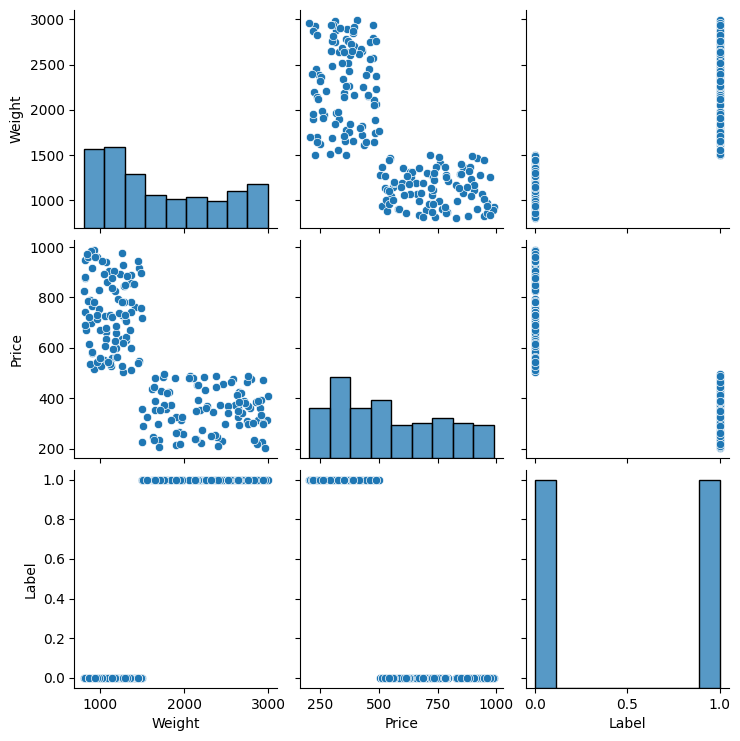

In [220]:
sns.pairplot(produk)
plt.show()

## **MODEL**

In [ ]:
X = produk.drop('Label', axis=1)
y = produk['Label']

In [222]:
# X = (X - X.min()) / (X.max() - X.min())
X = (X - X.mean()) / X - X.std()

In [223]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    train_0 = int(len(idx_0) * size)
    train_1 = int(len(idx_1) * size)

    train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
    test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    X_train = X.iloc[train_idx].values
    y_train = y.iloc[train_idx].values
    X_test = X.iloc[test_idx].values
    y_test = y.iloc[test_idx].values

    return X_train, y_train, X_test, y_test

In [224]:
X_train, y_train, X_test, y_test = split_data(X, y, size=0.8)
# y_train = np.array(y_train).reshape(-1, 1)
y_train = np.where(y_train <= 0, -1, 1)
y_train = np.array(y_train).flatten()

In [225]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(160, 2)
(160,)
(40, 2)
(40,)


In [226]:
def svm(X, y, learning_rate=0.01, lambda_param=0.01, iteration=1000):
    X = np.array(X)
    y = np.array(y)

    n_sample, n_feature = X.shape
    weights = np.zeros(n_feature)
    bias = 0

    for i in range(iteration):
        for idx, x_i in enumerate(X):
            condition = y[idx] * (np.dot(x_i, weights) + bias) >= 1
            if condition:
                weights -= learning_rate * (2 * lambda_param * weights)
            else:
                weights -= learning_rate * (2 * lambda_param * weights - (x_i * y[idx]))
                bias += learning_rate * y[idx]
    return weights, bias

In [227]:
def prediksi(X, weights, bias):
    X = np.array(X)
    linear = np.dot(X, weights) + bias
    return np.sign(linear)

In [228]:
best_w, best_b = svm(X_train, y_train, learning_rate=0.001, lambda_param=0.01, iteration=1000)

print(f"Weights akhir: {best_w}")
print(f"Bias akhir: {best_b}")

Weights akhir: [  4.0531487  -12.83759478]
Bias akhir: 0.026000000000000016


In [229]:
y_pred_train =  prediksi(X_train, best_w, best_b)
y_pred_test =  prediksi(X_test, best_w, best_b)

In [230]:
akurasi_train = np.mean(y_pred_train == y_train)
print(f"Akurasi Train:  {akurasi_train}")

Akurasi Train:  0.5


In [231]:
akurasi_test = np.mean(y_pred_test == y_test)
print(f"Akurasi Test:   {akurasi_test}")


Akurasi Test:   0.5


In [232]:
def evaluate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp - fp) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

In [233]:
acc_train, precision_train, recall_train, f1_train = evaluate(y_train, y_pred_train)
acc_test, precision_test, recall_test, f1_test = evaluate(y_test, y_pred_test)

print("Train")
print(f"- Akurasi: {acc_train}\n- Precision: {precision_train}\n- Recall: {recall_train}\n- F1: {f1_train}")
print("\nTest")
print(f"- Akurasi: {acc_test}\n- Precision: {precision_test}\n- Recall: {recall_test}\n- F1: {f1_test}")

Train
- Akurasi: 0.5
- Precision: 1.0
- Recall: 1.0
- F1: 1.0

Test
- Akurasi: 0.0
- Precision: 0.5
- Recall: 1.0
- F1: 0.6666666666666666


## **VISUALISASI**

In [234]:
# def plot(X, y, weigts, bias):
#     X = np.array(X)
#     y = np.array(y)
#     w = np.array(weigts)

#     plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
    
#     ax = plt.gca()
#     xlim = ax.get_xlim()
#     ylim = ax.get_ylim()

#     xx = np.linspace(xlim[0], xlim[1], 30)
#     yy = np.linspace(ylim[0], ylim[1], 30)
#     YY, XX = np.meshgrid(yy, xx)

#     Z = (w[0] * XX + w[1] * YY + bias)

#     ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], aplha=0.8, linestyleS=['--', '-', '--'])
#     plt.show()

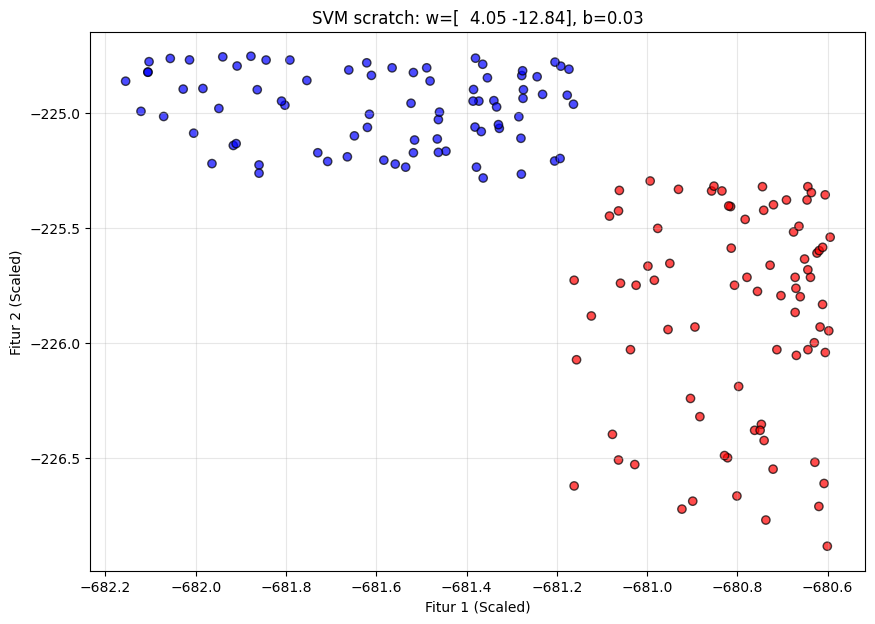

In [ ]:


# def visualize_svm_final(X, y, weights, bias):
#     X = np.array(X)
#     y = np.array(y)
#     w = np.array(weights)

#     plt.figure(figsize=(10, 7))

#     plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolors='k')

#     ax = plt.gca()
#     xlim = ax.get_xlim()
#     ylim = ax.get_ylim()

#     xx = np.linspace(xlim[0], xlim[1], 30)
#     yy = np.linspace(ylim[0], ylim[1], 30)
#     YY, XX = np.meshgrid(yy, xx)

#     Z = (w[0] * XX + w[1] * YY + bias)

#     ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8,
#                linestyles=['--', '-', '--'])

#     plt.title(f"SVM scratch: w={w.round(2)}, b={round(bias, 2)}")
#     plt.xlabel("Fitur 1 (Scaled)")
#     plt.ylabel("Fitur 2 (Scaled)")
#     plt.grid(True, alpha=0.3)
#     plt.show()

# visualize_svm_final(X_train, y_train, best_w, best_b)

In [236]:
# plot(X_train, y_train, best_w, best_b)

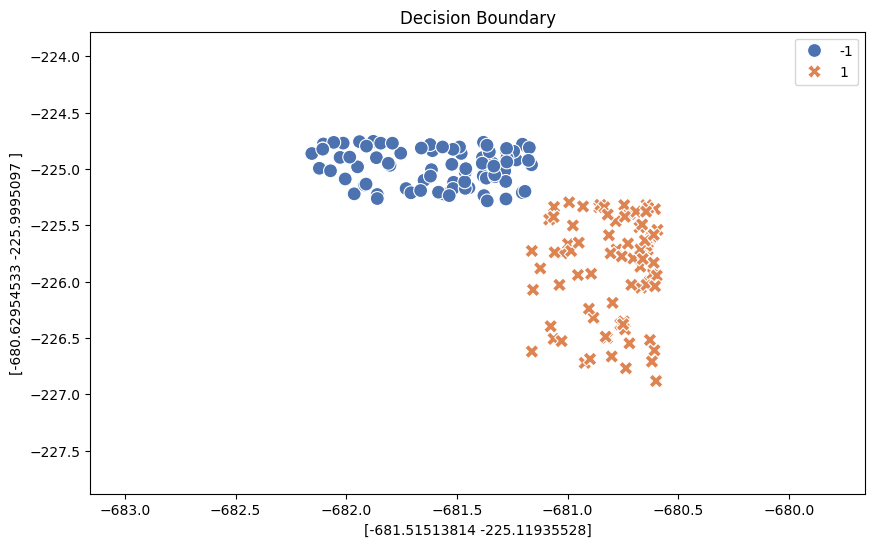

In [ ]:
# def plot_decision_boundary(X, y, weights, bias):
#     plt.figure(figsize=(10, 6))
    
#     # 1. Plot Scatter Data Asli
#     # Pastikan y diubah jadi array 1D kalau bentuknya dataframe
#     y_flat = np.array(y).flatten()
#     sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_flat, style=y_flat, palette='deep', s=100)
    
#     # 2. Siapkan Grid untuk Garis/Contour
#     x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
#     y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
#     xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
#                          np.arange(y_min, y_max, 0.1))
    
#     # 3. Hitung Prediksi untuk setiap titik di Grid
#     # Kita pakai rumus w1*x1 + w2*x2 + bias
#     grid_points = np.c_[xx.ravel(), yy.ravel()]
#     Z = np.dot(grid_points, weights) + bias
    
#     # Jika ini logistic regression (sigmoid), kita threshold di 0
#     # Jika perceptron biasa, threshold juga di 0
#     Z = Z.reshape(xx.shape)
    
#     # 4. Gambar Garis Kontur (Garis Batas)
#     # Level=[0] artinya kita gambar garis di mana hasil prediksinya 0 (batas antara positif/negatif)
#     plt.contour(xx, yy, Z, levels=[0], colors='red', linewidths=2)

#     plt.title("Decision Boundary")
#     plt.xlabel(X[0])
#     plt.ylabel(X[1])
#     plt.show()

# # Panggil fungsinya (ganti X_train, y_train, w, b sesuai variabelmu)
# plot_decision_boundary(X_train, y_train, best_w, best_b)

#### berat


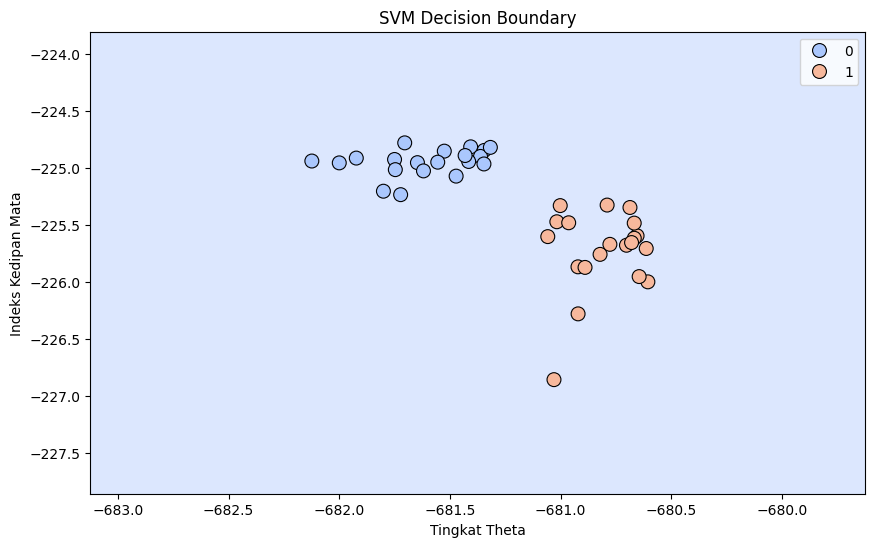

In [241]:
def plot_decision_boundary(X, y, weights, bias):
    # Pastikan X dan y adalah numpy array
    X = np.array(X)
    y = np.array(y)

    # Membuat meshgrid untuk ruang fitur
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Step size grid (0.1) bisa diperkecil biar lebih halus, misal 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # Menghitung prediksi untuk setiap titik di grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z = prediksi(grid_points, weights, bias)
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    Z_raw = np.dot(grid_points, weights) + bias
    Z_raw = Z_raw.reshape(xx.shape)

    plt.contour(xx, yy, Z_raw, colors='black', levels=[-1, 0, 1],
                alpha=0.5, linestyles=['--', '-', '--'])

    # Plot data asli
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='coolwarm', edgecolor='k', s=100)

    plt.title("SVM Decision Boundary")
    plt.xlabel("Tingkat Theta")
    plt.ylabel("Indeks Kedipan Mata")
    plt.show()

plot_decision_boundary(X_test, y_test, best_w, best_b)
